
# Análisis y procesamiento de señales
## Carranza Facundo TS8: Filtrado digital lineal de ECG

### Introducción teórica


#### En el procesamiento digital de señales, los filtros son herramientas esenciales para modificar el contenido espectral de una señal, ya sea eliminando, atenuando o conservando determinadas componentes de frecuencia. Entre los tipos de filtros más utilizados se encuentran los FIR (Finite Impulse Response) y los IIR (Infinite Impulse Response), que persiguen el mismo objetivo general pero difieren en su formulación matemática y en sus propiedades de fase, estabilidad y complejidad computacional.

#### Los filtros FIR poseen respuesta al impulso finita y pueden diseñarse con fase lineal exacta cuando sus coeficientes son simétricos o antisimétricos. Esto garantiza que todas las componentes de frecuencia sufran el mismo retardo, evitando la distorsión temporal. Su principal desventaja es que requieren un orden elevado para cumplir especificaciones exigentes, lo que aumenta el costo computacional. Aun así, son preferidos en aplicaciones donde la fidelidad temporal es prioritaria.

#### Los filtros IIR, en cambio, incluyen realimentación, por lo que su respuesta al impulso es teóricamente infinita. Su función de transferencia presenta polos y ceros, lo que les permite obtener respuestas en frecuencia muy selectivas con órdenes significativamente menores que los FIR. Esto los vuelve más eficientes, aunque a costa de una fase no lineal y la necesidad de verificar la estabilidad (los polos deben permanecer dentro del círculo unitario). Para reducir la distorsión de fase, suele aplicarse filtrado hacia adelante y hacia atrás (filtfilt), logrando una respuesta de fase efectiva cercana a cero.

#### En conjunto, ambos tipos de filtros forman un conjunto de herramientas complementarias para el diseño de sistemas capaces de limpiar, modelar y mejorar señales como el ECG analizado en este informe.

### Análisis, desarollo y Discusión


#### En este informe se analizarán distintos filtros digitales aplicados al procesamiento de una señal electrocardiográfica (ECG), con el objetivo de evaluar su capacidad para eliminar ruidos sin alterar la morfología característica del trazado cardíaco. Para ello se implementarán y compararán filtros de tipo IIR y FIR (incluyendo variantes como FIRLS), estudiando cómo cada uno atenúa interferencias provenientes del movimiento, actividad muscular (EMG) o ruido eléctrico, factores habituales en registros obtenidos durante pruebas de esfuerzo.

#### El análisis es especialmente relevante en el ámbito biomédico, ya que un ECG limpio permite realizar un diagnóstico más preciso. La señal a estudiar proviene del archivo ECG_TP4, y se buscará obtener un resultado lo más similar posible a un trazado ideal, con líneas suaves, nivel isoeléctrico estable y complejos QRS claramente definidos.

#### Para el diseño de filtros IIR se empleará la función iirdesign, que permite especificar parámetros clave como las frecuencias de banda de paso y rechazo (wp, ws), las atenuaciones permitidas o requeridas (gpass, gstop), el tipo de aproximación (Butterworth, Chebyshev, elíptico, etc.), y la frecuencia de muestreo. Los coeficientes obtenidos se expresarán en forma de secciones de segundo orden (SOS), que luego serán aplicadas a la señal mediante sosfilt, método que garantiza una implementación numéricamente estable.

#### En paralelo, se diseñarán filtros FIR utilizando distintas metodologías y se comparará su desempeño respecto de los IIR, con el fin de determinar cuál ofrece un mejor compromiso entre atenuación del ruido, preservación del contorno del ECG y costo computacional.

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import matplotlib.pyplot as plt
import scipy.io as sio

# Parámetros del filtro
wp = [0.8,35]   # banda de paso (Hz)
ws = [0.1, 40]  # banda de stop (Hz)
alpha_p = 1/2  # atenuación máxima en banda de paso [dB]
alpha_s = 40/2  # atenuación mínima en banda de rechazo [dB]
fs=1000  # frecuencias de muestreo [Hz]

# Diseño del filtro 
ni_sos_butter= signal.iirdesign(wp=wp, ws=ws, gpass=alpha_p, gstop=alpha_s,
                        analog=False, ftype='butter', output='sos',fs=fs)

ni_sos_cauer= signal.iirdesign(wp=wp, ws=ws, gpass=alpha_p, gstop=alpha_s,
                        analog=False, ftype='cauer', output='sos',fs=fs)

ni_sos_cheb1= signal.iirdesign(wp=wp, ws=ws, gpass=alpha_p, gstop=alpha_s,
                        analog=False, ftype='cheby1', output='sos',fs=fs)

ni_sos_cheb2= signal.iirdesign(wp=wp, ws=ws, gpass=alpha_p, gstop=alpha_s,
                        analog=False, ftype='cheby2', output='sos',fs=fs)

#### Con este código se generaron distintos filtros IIR mediante iirdesign, variando únicamente el parámetro ftype para obtener aproximaciones Butterworth, Cauer, Chebyshev I y Chebyshev II. Cada opción produce un conjunto diferente de coeficientes SOS, ya que cada familia de filtros se adapta a la plantilla con criterios distintos: máxima planitud, rizado controlado o transiciones más abruptas.

#### El objetivo es obtener una respuesta en magnitud que se aproxime al comportamiento ideal de un filtro brickwall, logrando buena atenuación fuera de banda. Esto suele implicar sacrificar la linealidad de fase, ya que los filtros IIR no garantizan fase constante, pero permiten cumplir especificaciones exigentes con órdenes mucho menores que los FIR.

#### A continuación se analiza la respuesta en magnitud, fase y retardo de grupo del filtro elíptico (Cauer) diseñado. Esto permite evaluar qué tan cerca está de un comportamiento ideal tipo brickwall en módulo y, al mismo tiempo, observar el compromiso que introduce en la fase y en el retardo de grupo, aspectos clave para determinar su impacto sobre la señal de ECG.

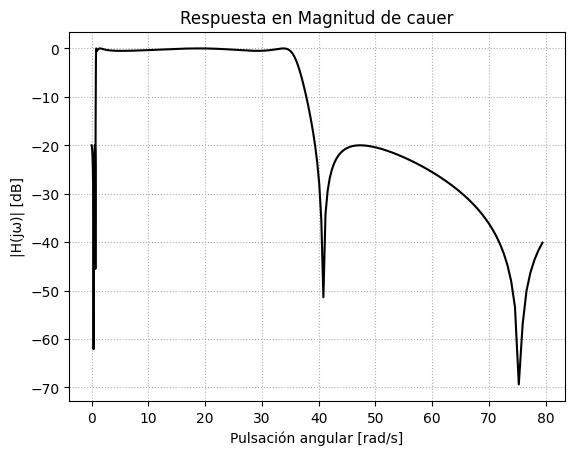

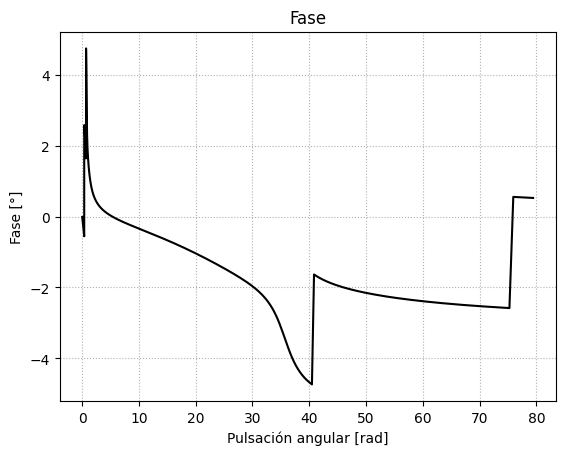

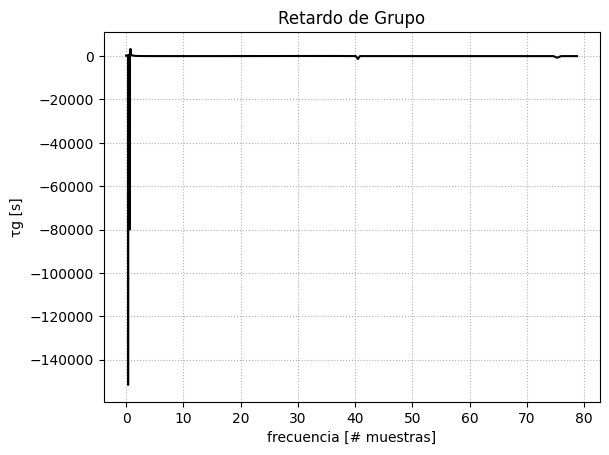

In [38]:
wcauer = np.logspace(-2, 1.9, 1000)
wcauer, hcauer = signal.freqz_sos(ni_sos_cauer, fs=fs, worN=wcauer) # w en Hz
wradcauer=wcauer/(fs/2)*np.pi # w en rad
# Fase y retardo de grupo
phasecauer = np.unwrap(np.angle(hcauer))
gdcauer = -np.diff(phasecauer) / np.diff(wradcauer)

# Magnitud
plt.figure()
plt.plot(wcauer, 20*np.log10(abs(hcauer)),color='black')
plt.title('Respuesta en Magnitud de cauer')
plt.xlabel('Pulsación angular [rad/s]')
plt.ylabel('|H(jω)| [dB]')
plt.grid(True, which='both', ls=':')

# Fase
plt.figure()
plt.plot(wcauer, phasecauer,color='black')
plt.title('Fase')
plt.xlabel('Pulsación angular [rad]')
plt.ylabel('Fase [°]')
plt.grid(True, which='both', ls=':')

# Retardo de grupo
plt.figure()
plt.plot(wcauer[:-1], gdcauer,color='black')
plt.title('Retardo de Grupo')
plt.xlabel('frecuencia [# muestras]')
plt.ylabel('τg [s]')
plt.grid(True, which='both', ls=':')

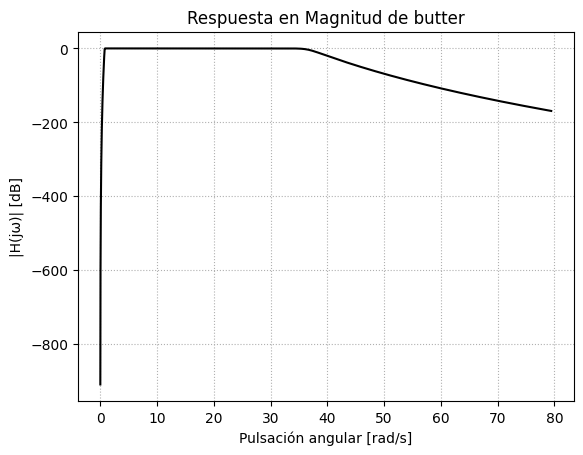

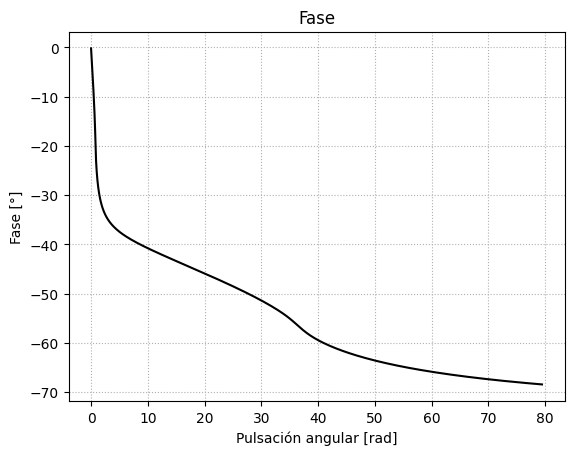

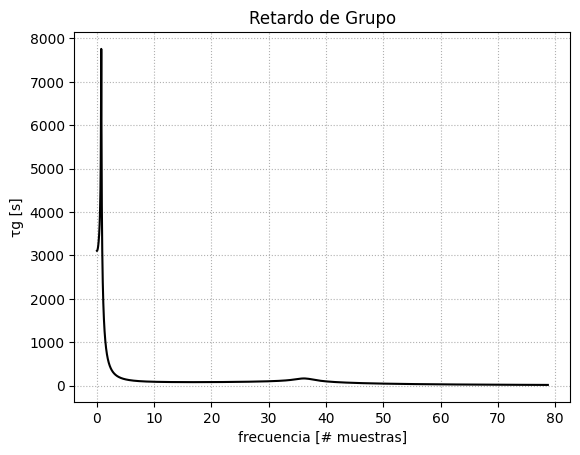

In [39]:
wbutter = np.logspace(-2, 1.9, 1000)
wbutter, hbutter = signal.freqz_sos(ni_sos_butter, fs=fs, worN=wbutter) # w en Hz
wradbutter=wbutter/(fs/2)*np.pi # w en rad
# Fase y retardo de grupo
phasebutter = np.unwrap(np.angle(hbutter))
gdbutter = -np.diff(phasebutter) / np.diff(wradbutter)

# Magnitud
plt.figure()
plt.plot(wbutter, 20*np.log10(abs(hbutter)),color='black')
plt.title('Respuesta en Magnitud de butter')
plt.xlabel('Pulsación angular [rad/s]')
plt.ylabel('|H(jω)| [dB]')
plt.grid(True, which='both', ls=':')

# Fase
plt.figure()
plt.plot(wbutter, phasebutter,color='black')
plt.title('Fase')
plt.xlabel('Pulsación angular [rad]')
plt.ylabel('Fase [°]')
plt.grid(True, which='both', ls=':')

# Retardo de grupo
plt.figure()
plt.plot(wbutter[:-1], gdbutter,color='black')
plt.title('Retardo de Grupo')
plt.xlabel('frecuencia [# muestras]')
plt.ylabel('τg [s]')
plt.grid(True, which='both', ls=':')

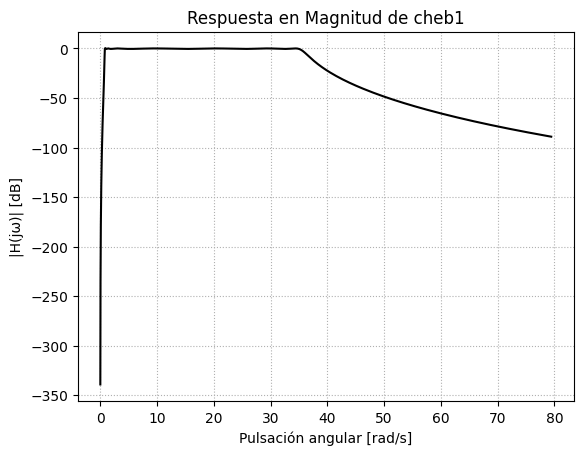

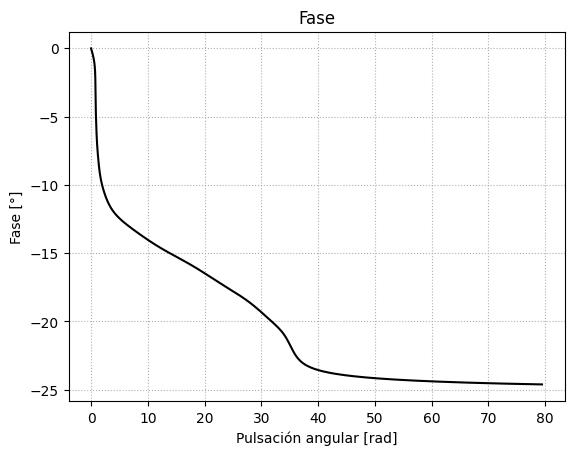

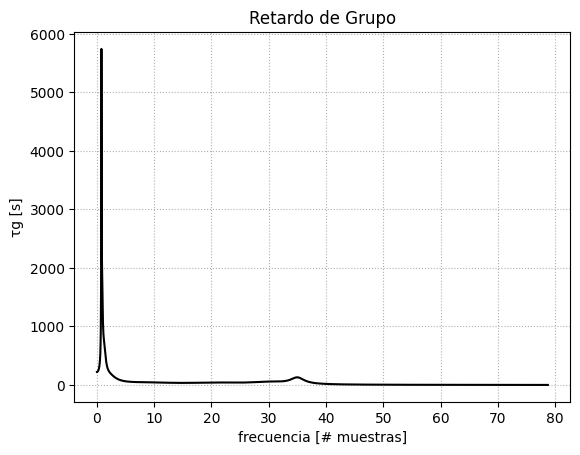

In [40]:
wcheb1 = np.logspace(-2, 1.9, 1000)
wcheb1, hcheb1 = signal.freqz_sos(ni_sos_cheb1, fs=fs, worN=wcheb1) # w en Hz
wradcheb1=wcheb1/(fs/2)*np.pi # w en rad
# Fase y retardo de grupo
phasecheb1 = np.unwrap(np.angle(hcheb1))
gdcheb1 = -np.diff(phasecheb1) / np.diff(wradcheb1)

# Magnitud
plt.figure()
plt.plot(wcheb1, 20*np.log10(abs(hcheb1)),color='black')
plt.title('Respuesta en Magnitud de cheb1')
plt.xlabel('Pulsación angular [rad/s]')
plt.ylabel('|H(jω)| [dB]')
plt.grid(True, which='both', ls=':')

# Fase
plt.figure()
plt.plot(wcheb1, phasecheb1,color='black')
plt.title('Fase')
plt.xlabel('Pulsación angular [rad]')
plt.ylabel('Fase [°]')
plt.grid(True, which='both', ls=':')

# Retardo de grupo
plt.figure()
plt.plot(wcheb1[:-1], gdcheb1,color='black')
plt.title('Retardo de Grupo')
plt.xlabel('frecuencia [# muestras]')
plt.ylabel('τg [s]')
plt.grid(True, which='both', ls=':')

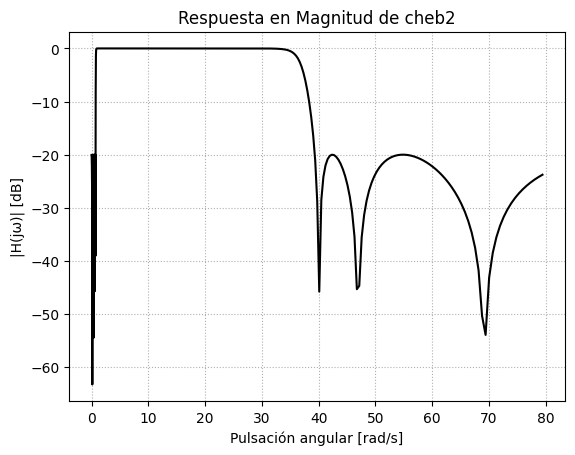

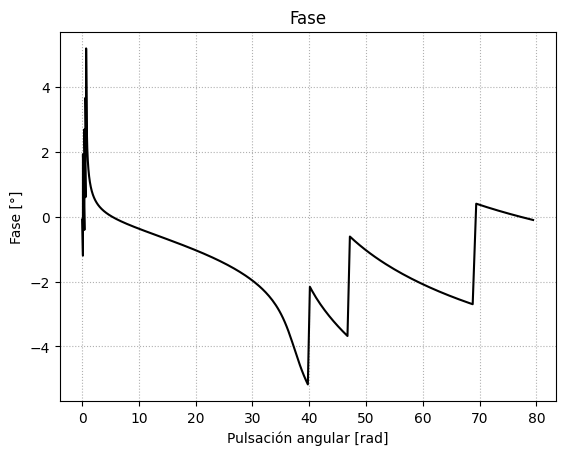

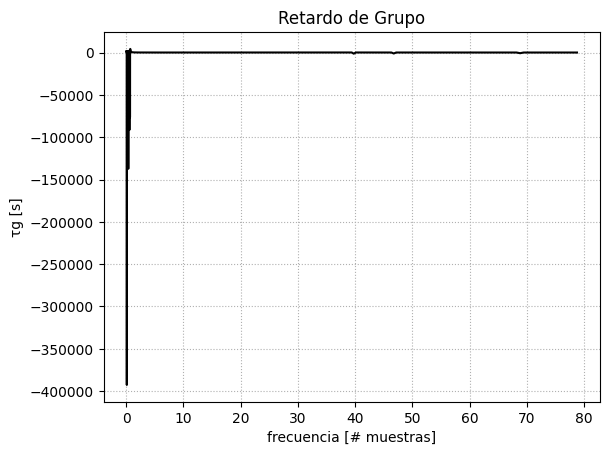

In [41]:
wcheb2 = np.logspace(-2, 1.9, 1000)
wcheb2, hcheb2 = signal.freqz_sos(ni_sos_cheb2, fs=fs, worN=wcheb2) # w en Hz
wradcheb2=wcheb2/(fs/2)*np.pi # w en rad
# Fase y retardo de grupo
phasecheb2 = np.unwrap(np.angle(hcheb2))
gdcheb2 = -np.diff(phasecheb2) / np.diff(wradcheb2)

# Magnitud
plt.figure()
plt.plot(wcheb2, 20*np.log10(abs(hcheb2)),color='black')
plt.title('Respuesta en Magnitud de cheb2')
plt.xlabel('Pulsación angular [rad/s]')
plt.ylabel('|H(jω)| [dB]')
plt.grid(True, which='both', ls=':')

# Fase
plt.figure()
plt.plot(wcheb2, phasecheb2,color='black')
plt.title('Fase')
plt.xlabel('Pulsación angular [rad]')
plt.ylabel('Fase [°]')
plt.grid(True, which='both', ls=':')

# Retardo de grupo
plt.figure()
plt.plot(wcheb2[:-1], gdcheb2,color='black')
plt.title('Retardo de Grupo')
plt.xlabel('frecuencia [# muestras]')
plt.ylabel('τg [s]')
plt.grid(True, which='both', ls=':')

#### Introduzco ahora la ecg con ruido

In [42]:
mat_struct = sio.loadmat('./ECG_TP4.mat')
ecg_one_lead = mat_struct['ecg_lead'].flatten()  # asume shape (N,1) o (1,N)
N = len(ecg_one_lead)

#### Una vez introducido procedemos a filtrarlo 

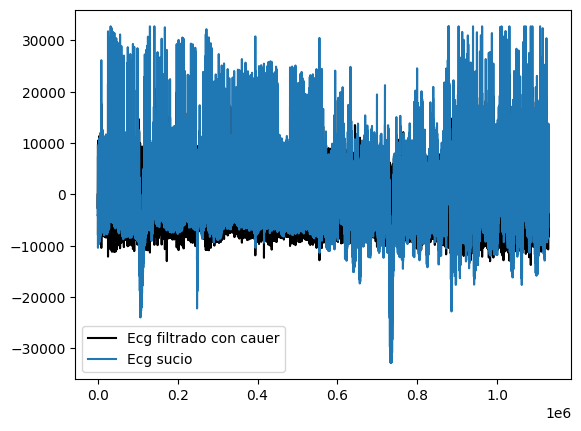

In [43]:
ecg_filt_cauer=signal.sosfilt(ni_sos_cauer, ecg_one_lead)

plt.figure()
plt.plot(ecg_filt_cauer, label='Ecg filtrado con cauer',color='black')
plt.plot(ecg_one_lead, label='Ecg sucio')
plt.legend()

#### Como no podemos analizar nada de esta manera, recortaremos una parte de ambas ECG, la filtrada y las no filtradas para poder ver que es lo que obtuvimos 

(-10000.0, 10500.0)

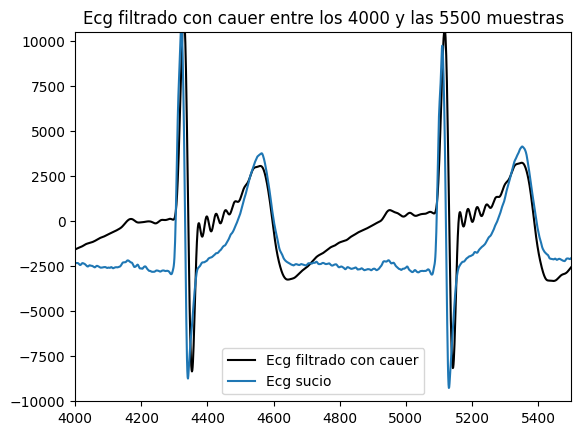

In [44]:
plt.figure()
plt.plot(ecg_filt_cauer, label='Ecg filtrado con cauer',color='black')
plt.plot(ecg_one_lead, label='Ecg sucio')
plt.legend()
plt.title('Ecg filtrado con cauer entre los 4000 y las 5500 muestras')
plt.xlim(4000,5500)
plt.ylim(-10000,10500)

#### Lo primero que se puede observar es que la señal filtrada se encuentra desfasada y reflejada. Esto puede deberse al desfase y al retardo de grupo no lineal característicos del tipo de filtro utilizado. Cuando se aplica un filtrado con este tipo de filtros, la señal de entrada x pasa a través de un sistema LTI, generando una salida y con una inversión de fase. Si se realizara un doble filtrado, se obtendría el módulo al cuadrado de la respuesta y una fase lineal, además de producirse una atenuación total equivalente al doble de la original. Dado que la atenuación de interés es de 40 dB, al inicio se indicó que corresponde a 40/2 dB por cada etapa de . Obteniendo asi el siguiente grafico 

(-10000.0, 10500.0)

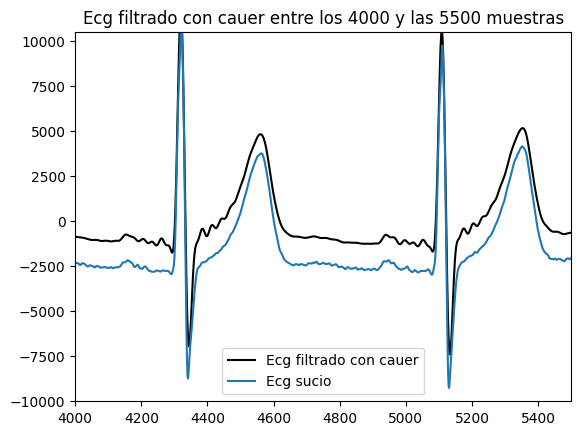

In [45]:
ecg_filt_cauer=signal.sosfiltfilt(ni_sos_cauer, ecg_one_lead)
plt.plot(ecg_filt_cauer, label='Ecg filtrado con cauer',color='black')
plt.plot(ecg_one_lead, label='Ecg sucio')
plt.legend()
plt.title('Ecg filtrado con cauer entre los 4000 y las 5500 muestras')
plt.xlim(4000,5500)
plt.ylim(-10000,10500)

#### Obteniendo asi un mejor filtro, ahora sabiendo esto para continuar con el infome analizaremos en distintas zonas de interes dadas por el profesor, el comportamiento de los filtros para poder determinar como este se comparta, tanto en la banda de stop, la banda de paso y la zonas de alta frecuencia.

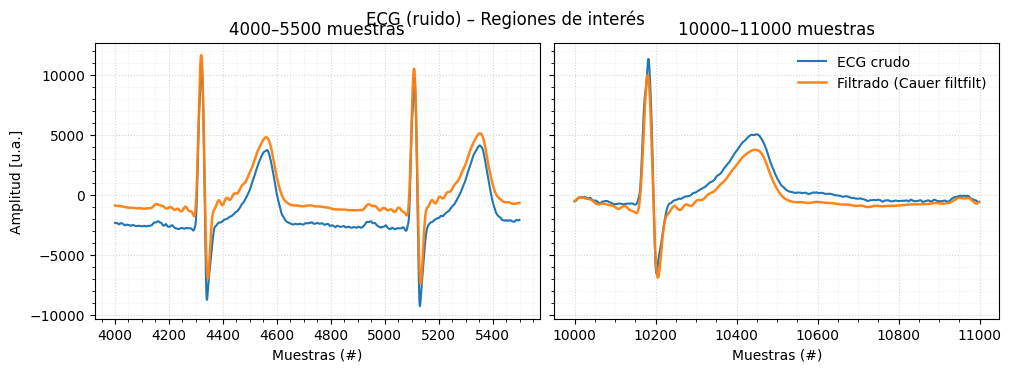

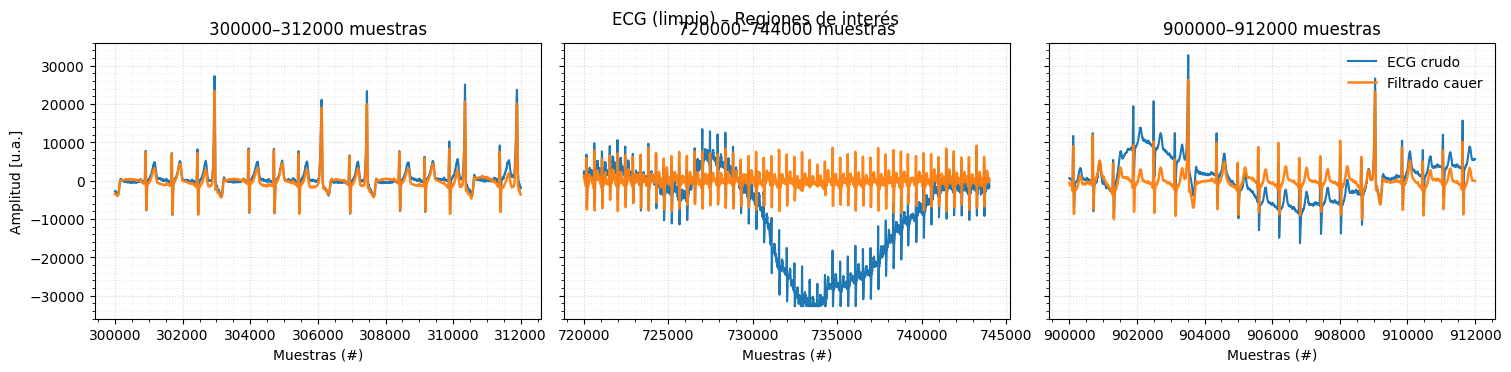

In [46]:
def _indices_roi(ii, N):
    i0 = int(max(0, np.floor(ii[0])))
    i1 = int(min(N, np.ceil(ii[1])))
    if i1 <= i0: i1 = min(N, i0+1)
    return i0, i1

def _dedup_legend(ax, loc='upper right'):
    # evita entradas repetidas en la leyenda
    handles, labels = ax.get_legend_handles_labels()
    seen = {}
    for h, l in zip(handles, labels):
        seen.setdefault(l, h)
    ax.legend(seen.values(), seen.keys(), frameon=False, loc=loc)

def _apply_delay_window(i0, i1, N, delay):
    """
    Recorta [i0, i1) para que 'idx' y 'idx+delay' sean válidos en [0, N).
    Devuelve: idx (np.arange recortado) e idx_filt = idx + delay.
    """
    # Si delay>0 corro la señal filtrada hacia la derecha: necesito idx <= N-1-delay
    # Si delay<0 corro hacia la izquierda: necesito idx >= -delay
    start = max(i0, max(0, -delay))
    stop  = min(i1, min(N, N - max(0, delay)))
    if stop <= start:
        # rango degenerado: devolveme un puntito válido para no crashear
        start = max(0, min(N-1, start))
        stop  = min(N, start+1)
    idx = np.arange(start, stop, dtype=int)
    idx_filt = idx + delay
    return idx, idx_filt

def _resolve_delay(delay_samples=None, delay_seconds=None, fs=1.0):
    if delay_seconds is not None:
        return int(np.round(delay_seconds * fs))
    return int(delay_samples or 0)

def plot_rois_samples(
    ecg_raw, ecg_filt, fs, regs_samples, title,
    *,
    delay_samples=None, delay_seconds=None,
    label_raw='ECG crudo', label_filt='Filtrado',
    legend_loc='upper right'
):
    """
    regs_samples: iterable de [i0, i1] en muestras
    delay_*: demora del filtro (positivo = desplaza la señal filtrada a la derecha)
    """
    N = len(ecg_raw)
    n = len(regs_samples)
    delay = _resolve_delay(delay_samples, delay_seconds, fs)

    fig, axs = plt.subplots(1, n, figsize=(5*n, 3.5), sharey=True, constrained_layout=True)
    if n == 1: axs = [axs]

    for ax, roi in zip(axs, regs_samples):
        i0, i1 = _indices_roi(roi, N)
        idx, idx_filt = _apply_delay_window(i0, i1, N, delay)

        ax.plot(idx,     ecg_raw[idx],   label=label_raw,  linewidth=1.5)
        ax.plot(idx,     ecg_filt[idx_filt], label=label_filt, linewidth=1.8, alpha=0.95)

        ax.set_title(f'{i0}–{i1} muestras')
        ax.set_xlabel('Muestras (#)')
        ax.grid(True, which='major', linestyle=':', alpha=0.5)
        ax.grid(True, which='minor', linestyle=':', alpha=0.2)
        ax.minorticks_on()

    axs[0].set_ylabel('Amplitud [u.a.]')
    fig.suptitle(title, y=1.02, fontsize=12)
    _dedup_legend(axs[-1], loc=legend_loc)
    plt.show()

def plot_rois_minutes(
    ecg_raw, ecg_filt, fs, regs_minutes, title,
    *,
    delay_samples=None, delay_seconds=None,
    label_raw='ECG crudo', label_filt='Filtrado',
    legend_loc='upper right'
):
    """
    regs_minutes: iterable de [min_ini, min_fin] en minutos
    """
    regs_samples = [np.array(r) * 60 * fs for r in regs_minutes]
    plot_rois_samples(
        ecg_raw, ecg_filt, fs, regs_samples, title,
        delay_samples=delay_samples, delay_seconds=delay_seconds,
        label_raw=label_raw, label_filt=label_filt, legend_loc=legend_loc
    )

# === Ejemplo de uso con tus variables ===
N = len(ecg_one_lead)
ecg_raw  = ecg_one_lead
ecg_filt = ecg_filt_cauer  

# --- ROIs en MUESTRAS (con ruido) ---
regs_ruido = (
    [4000, 5500],
    [10_000, 11_000],
)

# Caso 1: filtfilt (cero fase) → delay = 0 muestras
plot_rois_samples(
    ecg_raw, ecg_filt, fs, regs_ruido,
    title='ECG (ruido) – Regiones de interés',
    delay_samples=0,
    label_raw='ECG crudo',
    label_filt='Filtrado (Cauer filtfilt)',
    legend_loc='upper right'
)

# --- ROIs en MINUTOS (“limpio”) ---
regs_min = (
    [5.0, 5.2],
    [12.0, 12.4],
    [15.0, 15.2],
)

# Caso 2: filtro causal (ej. sosfilt) con retardo conocido, p.ej. 20 muestras
# (si preferís en segundos, usá delay_seconds=retardo_segundos)
plot_rois_minutes(
    ecg_raw, ecg_filt, fs, regs_min,
    title='ECG (limpio) – Regiones de interés',
    delay_samples=0,      
    label_raw='ECG crudo',
    label_filt='Filtrado cauer',
    legend_loc='upper right'
)

#### A continuación se aplicará el proceso de filtrado utilizando todos los tipos de filtros diseñados previamente. El objetivo es analizar y comparar el comportamiento de cada uno sobre la misma señal electrocardiográfica, evaluando su capacidad para eliminar el ruido sin alterar las componentes principales del ECG. Posteriormente, se graficarán las mismas regiones de interés, lo que permitirá observar las diferencias en la respuesta temporal y en la preservación de las características morfológicas de la señal original.

In [47]:
ecg_filt_butt=signal.sosfiltfilt(ni_sos_butter, ecg_one_lead)
ecg_filt_cheb1=signal.sosfiltfilt(ni_sos_cheb1, ecg_one_lead)
ecg_filt_cheb2=signal.sosfiltfilt(ni_sos_cheb2, ecg_one_lead)

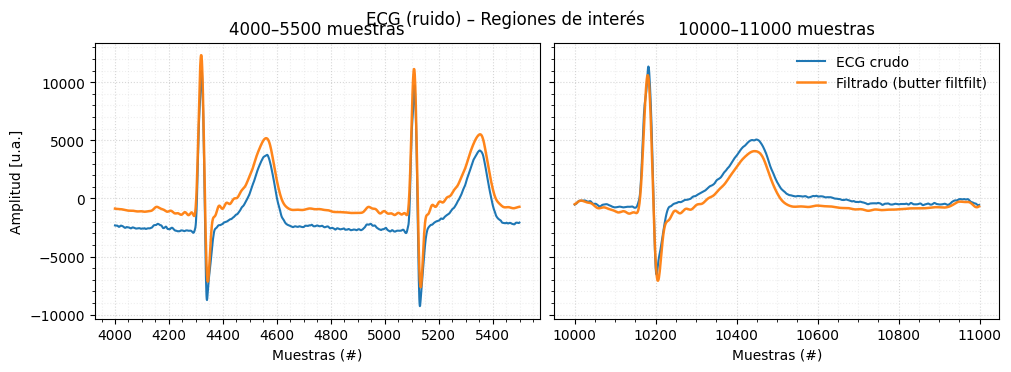

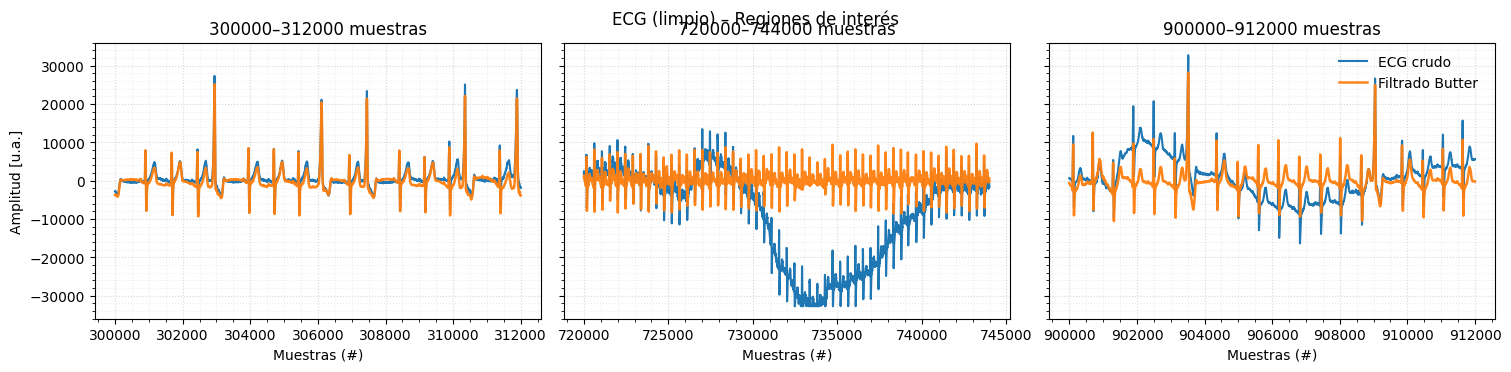

In [48]:

ecg_filt = ecg_filt_butt  

# --- ROIs en MUESTRAS (con ruido) ---
regs_ruido = (
    [4000, 5500],
    [10_000, 11_000],
)

# Caso 1: filtfilt (cero fase) → delay = 0 muestras
plot_rois_samples(
    ecg_raw, ecg_filt, fs, regs_ruido,
    title='ECG (ruido) – Regiones de interés',
    delay_samples=0,
    label_raw='ECG crudo',
    label_filt='Filtrado (butter filtfilt)',
    legend_loc='upper right'
)

# --- ROIs en MINUTOS (“limpio”) ---
regs_min = (
    [5.0, 5.2],
    [12.0, 12.4],
    [15.0, 15.2],
)

# Caso 2: filtro causal (ej. sosfilt) con retardo conocido, p.ej. 20 muestras
# (si preferís en segundos, usá delay_seconds=retardo_segundos)
plot_rois_minutes(
    ecg_raw, ecg_filt, fs, regs_min,
    title='ECG (limpio) – Regiones de interés',
    delay_samples=0,      
    label_raw='ECG crudo',
    label_filt='Filtrado Butter ',
    legend_loc='upper right'
)

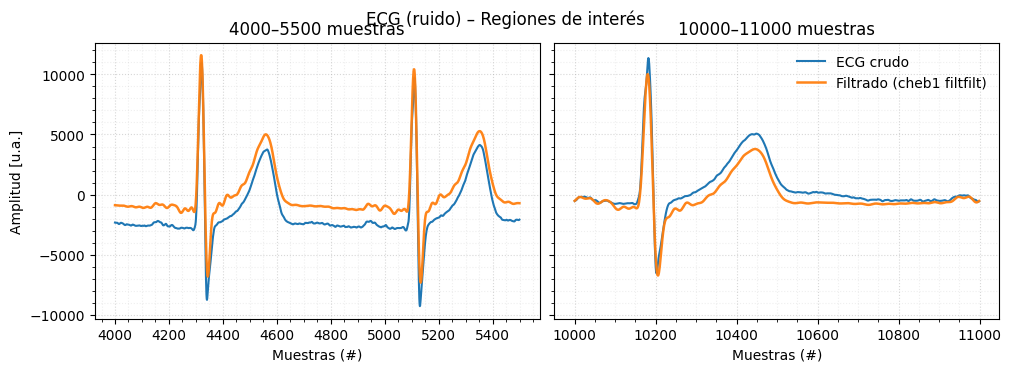

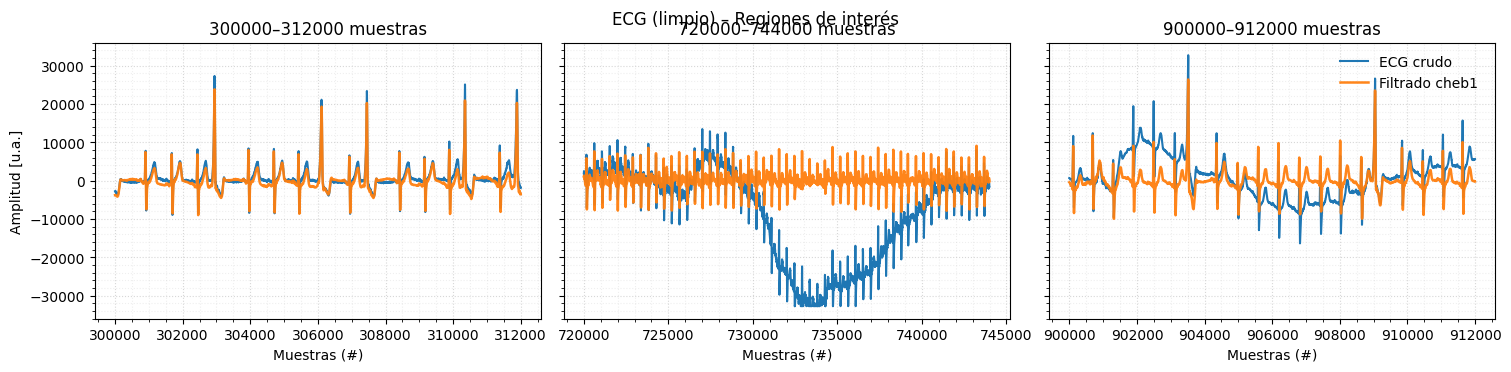

In [49]:

ecg_filt =ecg_filt_cheb1 

# --- ROIs en MUESTRAS (con ruido) ---
regs_ruido = (
    [4000, 5500],
    [10_000, 11_000],
)

# Caso 1: filtfilt (cero fase) → delay = 0 muestras
plot_rois_samples(
    ecg_raw, ecg_filt, fs, regs_ruido,
    title='ECG (ruido) – Regiones de interés',
    delay_samples=0,
    label_raw='ECG crudo',
    label_filt='Filtrado (cheb1 filtfilt)',
    legend_loc='upper right'
)

# --- ROIs en MINUTOS (“limpio”) ---
regs_min = (
    [5.0, 5.2],
    [12.0, 12.4],
    [15.0, 15.2],
)

# Caso 2: filtro causal (ej. sosfilt) con retardo conocido, p.ej. 20 muestras
# (si preferís en segundos, usá delay_seconds=retardo_segundos)
plot_rois_minutes(
    ecg_raw, ecg_filt, fs, regs_min,
    title='ECG (limpio) – Regiones de interés',
    delay_samples=0,      
    label_raw='ECG crudo',
    label_filt='Filtrado cheb1 ',
    legend_loc='upper right'
)

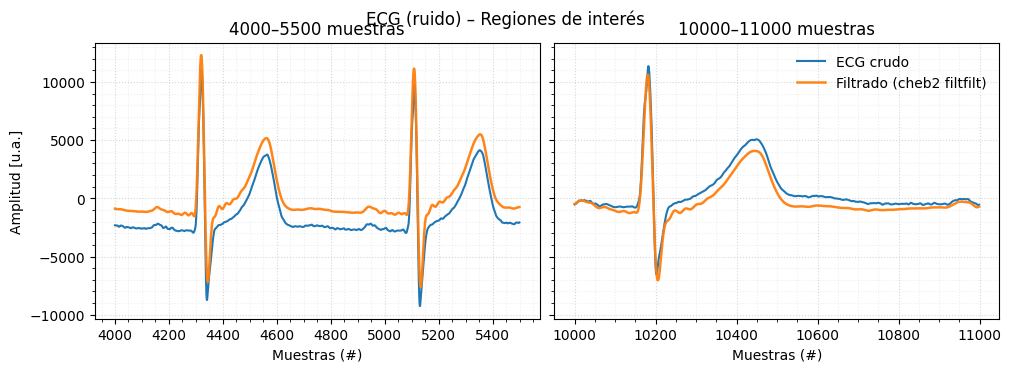

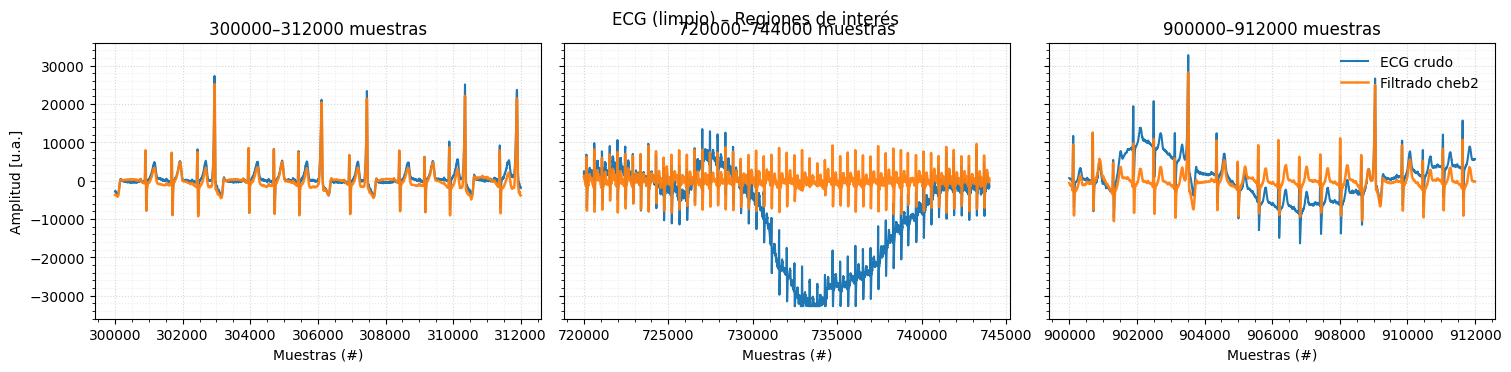

In [50]:

ecg_filt =ecg_filt_cheb2

# --- ROIs en MUESTRAS (con ruido) ---
regs_ruido = (
    [4000, 5500],
    [10_000, 11_000],
)

# Caso 1: filtfilt (cero fase) → delay = 0 muestras
plot_rois_samples(
    ecg_raw, ecg_filt, fs, regs_ruido,
    title='ECG (ruido) – Regiones de interés',
    delay_samples=0,
    label_raw='ECG crudo',
    label_filt='Filtrado (cheb2 filtfilt)',
    legend_loc='upper right'
)

# --- ROIs en MINUTOS (“limpio”) ---
regs_min = (
    [5.0, 5.2],
    [12.0, 12.4],
    [15.0, 15.2],
)

# Caso 2: filtro causal (ej. sosfilt) con retardo conocido, p.ej. 20 muestras
# (si preferís en segundos, usá delay_seconds=retardo_segundos)
plot_rois_minutes(
    ecg_raw, ecg_filt, fs, regs_min,
    title='ECG (limpio) – Regiones de interés',
    delay_samples=0,      
    label_raw='ECG crudo',
    label_filt='Filtrado cheb2 ',
    legend_loc='upper right'
)

#### Para analizar los filtros FIR se empleará la función firwin2 de scipy.signal, la cual permite diseñar un filtro a partir de una respuesta en frecuencia especificada. Este método requiere definir algunos parámetros clave. El más importante es numtaps, que indica la cantidad de coeficientes del filtro: valores altos permiten aproximar mejor la respuesta ideal, aunque a costa de un mayor uso de cómputo.

#### El parámetro freq contiene las frecuencias de diseño entre 0 y la frecuencia de Nyquist, mientras que gain especifica la ganancia deseada en cada uno de esos puntos. Además, el argumento window permite elegir la ventana utilizada en el diseño, lo cual influye directamente en el ancho de los lóbulos laterales y en la nitidez de la banda de transición. Por último, fs define la frecuencia de muestreo y nfreqs controla la resolución empleada para interpolar la respuesta objetivo.

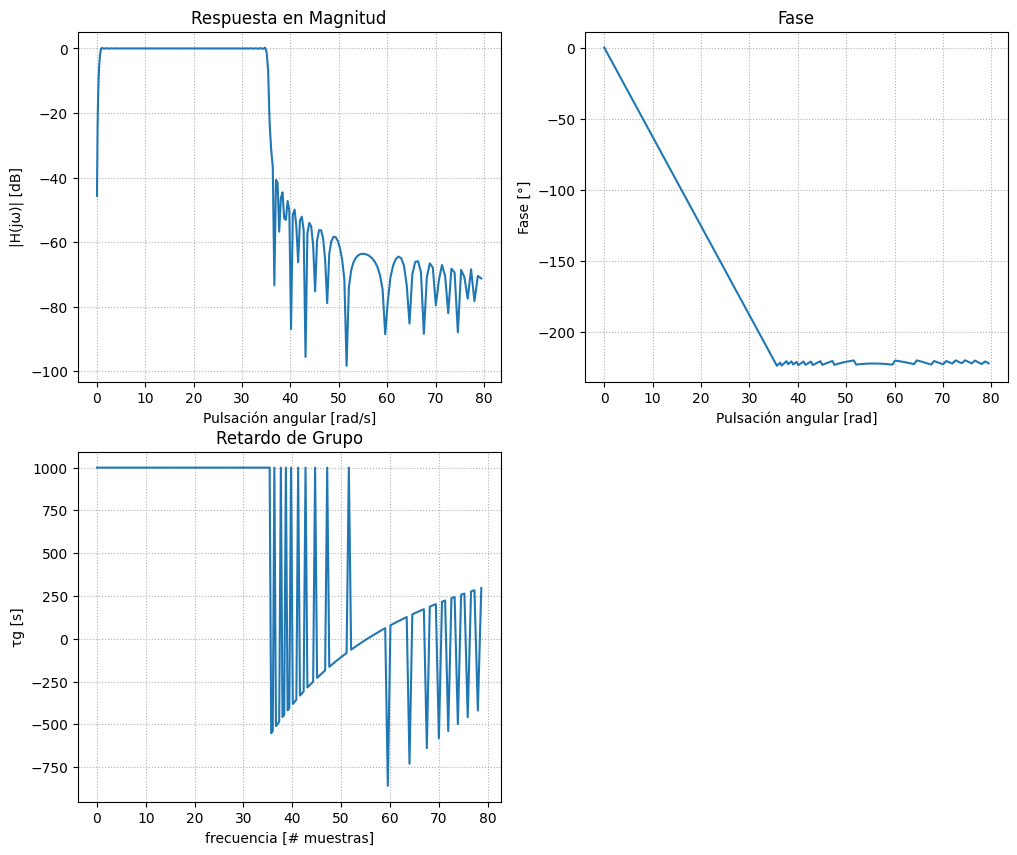

In [51]:
wp = [0.8,35]   # banda de pa so (Hz) # contar como modificar la banda de paso y la banda de stop para que tengan el mismo cambio mejora el filtro
ws = [0.1,35.7]  # banda de stop (Hz)
frecuencia=np.sort(np.concatenate(((0, fs/2), wp, ws) ))
deseado = [0,0,1,1,0,0]
numtaps=2000#cantidad de coeficientes 
retardo=(numtaps-1)//2
fir_win_rect=signal.firwin2(numtaps=numtaps, freq=frecuencia, gain=deseado, window='boxcar',nfreqs= int(np.ceil(np.sqrt(numtaps)*8))**2-1,fs=fs) #probar distitas ventanas de labulos mas anchos y mostrar que el filtro empeora
# Respuesta en frecuencia
w = np.logspace(-2, 1.9, 1000)
w, h = signal.freqz(fir_win_rect, fs=fs, worN=w) 
wrad=w/(fs/2)*np.pi # w en rad
# Fase y retardo de grupo
phase = np.unwrap(np.angle(h))
gd = -np.diff(phase) / np.diff(wrad)

#--- Gráficas ---
plt.figure(figsize=(12,10))

# Magnitud
plt.subplot(2,2,1)
plt.plot(w, 20*np.log10(abs(h)))
plt.title('Respuesta en Magnitud')
plt.xlabel('Pulsación angular [rad/s]')
plt.ylabel('|H(jω)| [dB]')
plt.grid(True, which='both', ls=':')

# Fase
plt.subplot(2,2,2)
plt.plot(w, phase)
plt.title('Fase')
plt.xlabel('Pulsación angular [rad]')
plt.ylabel('Fase [°]')
plt.grid(True, which='both', ls=':')

# Retardo de grupo
plt.subplot(2,2,3)
plt.plot(w[:-1], gd)
plt.title('Retardo de Grupo')
plt.xlabel('frecuencia [# muestras]')
plt.ylabel('τg [s]')
plt.grid(True, which='both', ls=':')


### Conclusiones


#### En este trabajo se diseñaron y compararon filtros digitales FIR e IIR aplicados a un registro de ECG con el objetivo de eliminar ruido sin alterar la morfología cardíaca. Los filtros IIR (Butterworth, Chebyshev I y II, y Cauer) permitieron cumplir la plantilla de diseño con órdenes bajos, aunque con fase no lineal que fue corregida mediante filtfilt. Los filtros FIR, diseñados con firwin2, FIRLS y Parks–McClellan, mostraron una respuesta de fase más estable, pero requirieron un mayor número de coeficientes.

#### Al aplicar los filtros a distintas regiones del ECG, tanto ruidosas como limpias, se observó que todos los filtros que respetan la plantilla producen resultados similares debido al ancho de banda limitado del ECG. Todos lograron atenuar el ruido de baja y alta frecuencia manteniendo intacta la morfología del complejo QRS y el nivel isoeléctrico.

#### En conclusión, el proyecto permitió verificar que un diseño adecuado de la plantilla y el uso de filtrado de fase cero garantizan un procesamiento eficaz del ECG, y que tanto FIR como IIR pueden ofrecer un rendimiento comparable cuando se ajustan correctamente a los requerimientos de la señal biomédica.